**AI-Based Insurance Claim Fraud Detection System**

🔷 *****1. Introduction*****

In today’s digital era, insurance companies handle a massive volume of claims across multiple domains such as health, vehicle, and property insurance. These claims contain valuable information about customer behavior, risk patterns, and financial transactions. However, a small percentage of fraudulent claims leads to significant financial losses and operational inefficiencies.

Traditional fraud detection methods rely heavily on manual reviews and rule-based systems. These approaches are often slow, inefficient, and unable to detect complex or evolving fraud patterns. Fraudsters continuously adapt their techniques, making it difficult for static systems to identify suspicious activities.

To address these challenges, this project focuses on developing an AI-powered Insurance Claim Fraud Detection System. The system leverages machine learning techniques to analyze claim data, identify anomalies, and predict fraud probability, enabling faster and more accurate decision-making

*****🔷 2. Problem Statement*****

Insurance companies face several challenges in fraud detection:

* Manual claim verification is time-consuming and inefficient
* Rule-based systems fail to detect complex fraud patterns
* Fraudsters continuously evolve their strategies
* High false positives affect genuine customers
* Lack of intelligent systems to analyze:
    * Claim amount
    * Customer details
    * Claim history
    * Policy information
    * Incident reports

The goal is to develop a system that:
  * Detects fraudulent claims accurately
  * Reduces false positives
  * Supports investigation teams with insights
  * Improves operational efficiency

*****🔷 3. Objectives*****

The main objectives of this project are
* Analyze insurance claim data effectively
* Predict fraud probability for each claim
* Detect anomalous or suspicious claim patterns
* Minimize false positives while maintaining high accuracy
* Provide actionable insights for fraud investigation teams
* Improve customer experience by reducing delays

*****🔷 4. Dataset Description*****

📌 Dataset Name:

Insurance Fraud Detection Dataset (your CSV: fraud_oracle.csv)

📌 Features include:

Based on your problem statement and typical fraud datasets:
  * Claim Amount
  * Customer Age / Details
  * Policy Type
  * Claim History
  * Incident Type
  * Incident Severity
  * Vehicle / Property Details
  * Number of Previous Claims
  * Fraud Label (Target variable)

📌 Data Type:
 * Numerical + Categorical data
 * Supervised learning dataset (fraud = 0/1)

********🔷 5. Code********

🔹 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.utils import resample

🔹 2. Load Dataset

In [2]:
df = pd.read_csv("fraud_oracle.csv") 

print(df.head())
print(df.info())
print(df.columns)

  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  AgeOfVehicle  \
0          Jan                   1  Female        Single  ...       3 years   
1          Jan                   4    Male        Single  ...       6 years   
2          Nov                   2    Male       Married  ...       7 years   
3          Jul                   1    Male       Married  ...   more than 7   
4          Feb                   2  Female        Single  ...       5 years   

  AgeOfPolicyHolder PoliceReportFiled WitnessPresent AgentType  \
0          26 to 30 

🔹 3. Data Preprocessing

✅ Handle Missing Values And Dropping unnecessary columns

In [3]:
# Drop unnecessary columns if exist
df.drop(columns=['PolicyNumber'], errors='ignore', inplace=True)

# Handle missing values
df.ffill(inplace=True)

✅ Encode Categorical Data

In [4]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    
X = df.drop("FraudFound_P", axis=1)   # target column (check name if different)
y = df["FraudFound_P"]

🔸 Feature Selection

In [5]:
# Combine
data = pd.concat([X, y], axis=1)

# Separate classes
fraud = data[data["FraudFound_P"] == 1]
normal = data[data["FraudFound_P"] == 0]

# Upsample fraud
fraud_upsampled = resample(fraud,replace=True,n_samples=len(normal),random_state=42)

# Combine balanced data
balanced = pd.concat([normal, fraud_upsampled])

X = balanced.drop("FraudFound_P", axis=1)
y = balanced["FraudFound_P"]

🔹 4. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

🔹 5. Feature Scaling

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

🔹 6. Model Building 

○ Logistic Regression

In [8]:
LR = LogisticRegression()

LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression
[[1731 1153]
 [ 316 2599]]
              precision    recall  f1-score   support

           0       0.85      0.60      0.70      2884
           1       0.69      0.89      0.78      2915

    accuracy                           0.75      5799
   macro avg       0.77      0.75      0.74      5799
weighted avg       0.77      0.75      0.74      5799



○ Random Forest

In [9]:
RF = RandomForestClassifier(n_estimators=100)

RF.fit(X_train, y_train)

y_pred = RF.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest
[[2880    4]
 [   0 2915]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2884
           1       1.00      1.00      1.00      2915

    accuracy                           1.00      5799
   macro avg       1.00      1.00      1.00      5799
weighted avg       1.00      1.00      1.00      5799



○ Isolation Forest


In [10]:
iso = IsolationForest(contamination=0.1)

iso.fit(X_train)

y_pred_iso = iso.predict(X_test)

# Convert output (-1 → fraud, 1 → normal)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

print("Isolation Forest")
print(confusion_matrix(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso))

Isolation Forest
[[2558  326]
 [2629  286]]
              precision    recall  f1-score   support

           0       0.49      0.89      0.63      2884
           1       0.47      0.10      0.16      2915

    accuracy                           0.49      5799
   macro avg       0.48      0.49      0.40      5799
weighted avg       0.48      0.49      0.40      5799



In [11]:
cv_scores = cross_val_score(RF, X, y, cv=5, scoring='recall')

print("Cross-validation Recall:", cv_scores)
print("Average Recall:", cv_scores.mean())

Cross-validation Recall: [1. 1. 1. 1. 1.]
Average Recall: 1.0


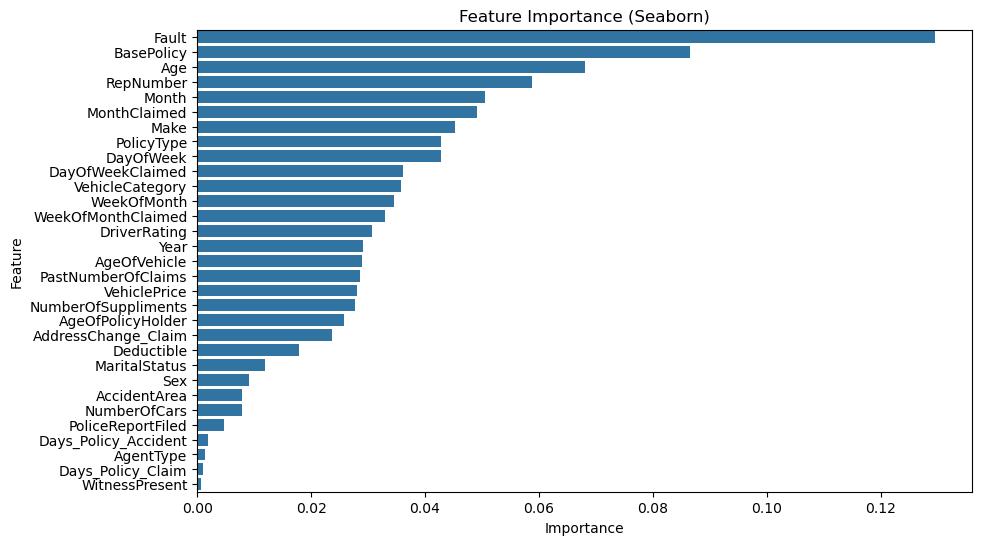

In [12]:
importances = RF.feature_importances_
feature_names = df.drop("FraudFound_P", axis=1).columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance (Seaborn)")
plt.show()

Evaluation

Accuracy: 0.9993


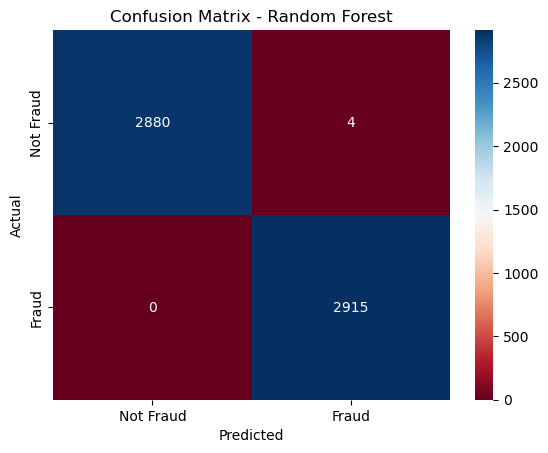


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2884
           1       1.00      1.00      1.00      2915

    accuracy                           1.00      5799
   macro avg       1.00      1.00      1.00      5799
weighted avg       1.00      1.00      1.00      5799



In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu',xticklabels=['Not Fraud', 'Fraud'],yticklabels=['Not Fraud', 'Fraud'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

🔹 7. Fraud Probability Prediction

In [15]:
probabilities = RF.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "Actual": y_test,
    "Fraud_Probability": probabilities
})

print(risk_df.head())

       Actual  Fraud_Probability
3084        0               0.00
13009       0               0.00
13217       0               0.06
5228        1               1.00
12213       1               1.00


***🔹 8.Conclusion***

The AI-powered fraud detection system enables insurance companies to transition from reactive to proactive fraud detection. By leveraging machine learning algorithms, the system can efficiently analyze large datasets, detect suspicious patterns, and predict fraudulent claims with high accuracy.

This approach not only reduces financial losses but also improves operational efficiency and enhances customer satisfaction by minimizing delays in genuine claims.